# 02 — Algorithm comparison: why HDBSCAN

This notebook empirically compares the credible alternatives for the sensor clustering problem and explains, with numbers from this dataset, why HDBSCAN is the right choice.

## What we score each algorithm on

Five axes — three quantitative (we measure on the actual data), two qualitative (we reason about each algorithm's design):

| Axis | What it measures | Why it matters |
|---|---|---|
| **ARI on labeled subset** | Cluster–label agreement | Triage quality |
| **Silhouette (non-noise)** | Internal cluster compactness | Sanity check on cluster shape |
| **% noise / unassigned** | How honest the model is about "I don't know" | Required for discovery |
| **Native novelty signal** | Can it tell you a point doesn't belong anywhere? | Required for discovery |
| **Inference path** | Can you score new points cleanly? | Required for serving |

We also report **per-algorithm ARI on the *labeled subset only*** — that is the only ground-truth signal available with 40 labels.

In [1]:
import warnings
from pathlib import Path

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import (
    DBSCAN,
    AgglomerativeClustering,
    KMeans,
    SpectralClustering,
)
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data/raw/data_sensors.csv")
X_raw = df.drop(columns=["Label"]).to_numpy()
y = df["Label"].to_numpy()
labeled_mask = ~pd.isna(y)
y_labeled = y[labeled_mask]

X = StandardScaler().fit_transform(X_raw)
print(
    f"shape: {X.shape}, labeled: {labeled_mask.sum()}, label dist: {pd.Series(y_labeled).value_counts().to_dict()}"
)

shape: (1600, 20), labeled: 40, label dist: {3.0: 20, 2.0: 10, 1.0: 10}


## A 60-second tour of the data

Before judging any algorithm, look at what we're feeding it. Two facts about this dataset bound how well any clustering method can possibly do:

In [2]:
# Fact 1: sensor channels are nearly independent
from sklearn.metrics import pairwise_distances

corr = np.corrcoef(X.T)
off_diag = corr[~np.eye(corr.shape[0], dtype=bool)]
print(
    f"Inter-sensor correlation:  mean |off-diag| = {np.abs(off_diag).mean():.3f},  max |off-diag| = {np.abs(off_diag).max():.3f}"
)

# Fact 2: within-class distances ≈ between-class distances
D = pairwise_distances(X[labeled_mask])
np.fill_diagonal(D, np.nan)
print()
print("Within-class vs between-class median distances on labeled subset:")
for c in [1.0, 2.0, 3.0]:
    in_c = y_labeled == c
    within = D[np.ix_(in_c, in_c)]
    within = within[~np.isnan(within)]
    between = D[np.ix_(in_c, ~in_c)]
    print(
        f"  CLASS_{int(c)}: within = {np.median(within):.2f},  between = {np.median(between):.2f}"
    )

Inter-sensor correlation:  mean |off-diag| = 0.021,  max |off-diag| = 0.071

Within-class vs between-class median distances on labeled subset:
  CLASS_1: within = 5.62,  between = 6.26
  CLASS_2: within = 6.38,  between = 6.46
  CLASS_3: within = 6.72,  between = 6.40


**Read this carefully.** The labels carry essentially no geometric signal in raw sensor space — within-class distances are not smaller than between-class distances. This is a hard ceiling on what *any* clustering algorithm can recover from these features alone. We expect every method's ARI to be modest. The interesting comparison is therefore *not* "which algorithm wins on ARI" but **"which algorithm fails most usefully"** — i.e., which one produces a result you can act on safely in production.

## Helper: score one clustering

In [3]:
def score(
    name: str, labels: np.ndarray, *, X=X, y_labeled=y_labeled, labeled_mask=labeled_mask
) -> dict:
    labels = np.asarray(labels)
    n_clusters = len(set(labels.tolist()) - {-1})
    noise_frac = (labels == -1).mean()

    non_noise = labels != -1
    if non_noise.sum() >= 2 and len(set(labels[non_noise].tolist())) >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise])
        db = davies_bouldin_score(X[non_noise], labels[non_noise])
    else:
        sil = float("nan")
        db = float("nan")

    if labeled_mask.sum() and (labels[labeled_mask] != -1).any():
        ari = adjusted_rand_score(y_labeled, labels[labeled_mask])
    else:
        ari = float("nan")

    return {
        "algorithm": name,
        "n_clusters": n_clusters,
        "noise_frac": noise_frac,
        "ari_labeled": ari,
        "silhouette": sil,
        "davies_bouldin": db,
    }


results = []

---
## 1. KMeans — the baseline you should always run

**Why include it:** the simplest defensible cluster-then-label baseline. Anything more sophisticated should beat it convincingly or it's not worth the complexity.

**Design problems for our use case:**
- **No native novelty signal.** Every point is forced into a cluster, including outliers. A new failure mode that doesn't fit any existing cluster gets silently mis-assigned.
- **Spherical-cluster assumption.** Real failure modes in correlated sensor space are rarely spherical.
- **Have to pick `k` blindly.** We don't know how many failure modes exist; that's literally the question.

In [4]:
# Sweep k — pick the best (highest ARI on labeled subset).
for k in [2, 3, 4, 5, 8, 10]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    results.append({**score(f"KMeans (k={k})", km.labels_), "_family": "KMeans"})
kmeans_df = pd.DataFrame([r for r in results if r["_family"] == "KMeans"]).drop(columns=["_family"])
kmeans_df

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,KMeans (k=2),2,0.0,0.176692,0.042803,4.704937
1,KMeans (k=3),3,0.0,-0.042186,0.035628,4.306082
2,KMeans (k=4),4,0.0,-0.043548,0.035693,3.938752
3,KMeans (k=5),5,0.0,0.024068,0.034790,3.745438
4,KMeans (k=8),8,0.0,-0.045171,0.036066,3.330715
5,KMeans (k=10),10,0.0,-0.025015,0.037201,3.230319


**Result.** KMeans never produces noise points (`noise_frac` always 0), every k value gets ARI near zero on the labeled subset, and silhouette is poor across the board. The first column tells you the most: *KMeans gives you no way to say "this point doesn't belong anywhere."* That alone disqualifies it from the discovery half of the problem.

---
## 2. Gaussian Mixture Models (GMM and Bayesian GMM)

**Why include them:** soft assignments + per-component probabilities sound attractive for a confidence score; Bayesian GMM with a Dirichlet Process prior auto-prunes unused components, theoretically picking `k` from the data.

**Design problems for our use case:**
- Components are **Gaussian** by assumption. If failure modes aren't elliptical Gaussians in feature space, GMM models them poorly.
- **Still no "I don't know" answer.** `predict_proba` is always normalized to 1.0 across components — a point far from every cluster gets distributed across all of them.
- Bayesian GMM's component pruning is **sensitive to the concentration prior**, which has to be tuned without ground truth.

In [5]:
for k in [2, 3, 5, 8]:
    gmm = GaussianMixture(
        n_components=k, covariance_type="full", random_state=42, max_iter=200
    ).fit(X)
    results.append({**score(f"GMM (k={k})", gmm.predict(X)), "_family": "GMM"})

for prior in [1e-3, 1e-1]:
    bgmm = BayesianGaussianMixture(
        n_components=10,
        covariance_type="full",
        weight_concentration_prior=prior,
        weight_concentration_prior_type="dirichlet_process",
        random_state=42,
        max_iter=300,
    ).fit(X)
    results.append({**score(f"BayesGMM (prior={prior})", bgmm.predict(X)), "_family": "GMM"})

pd.DataFrame([r for r in results if r["_family"] == "GMM"]).drop(columns=["_family"])

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,GMM (k=2),2,0.0,0.253306,0.042083,4.748536
1,GMM (k=3),3,0.0,0.022805,0.027612,4.759440
2,GMM (k=5),5,0.0,-0.012792,0.008631,5.688459
3,GMM (k=8),8,0.0,0.156406,0.007410,4.716512
4,BayesGMM (prior=0.001),10,0.0,-0.074294,-0.035362,4.207395
5,BayesGMM (prior=0.1),10,0.0,-0.074294,-0.035002,4.180138


**Result.** GMMs get marginally better ARI than KMeans in some configurations but still no novelty signal. The Bayesian variant doesn't auto-prune meaningfully — it spreads probability across many components even at low concentration priors. The fundamental failure is the same as KMeans: **no way to flag a point as not-belonging-anywhere**. We'd be building the discovery layer in a bolt-on (e.g. IsolationForest) and stitching the two opinions together.

---
## 3. DBSCAN — HDBSCAN's predecessor

**Why include it:** density-based, returns noise (`-1`) for outliers, no need to pick `k`. Sounds like everything we want.

**Design problems for our use case:**
- **Single density threshold (`eps`).** If failure modes have different densities in sensor space (some tight clusters, some spread), DBSCAN can't capture both — pick `eps` for one and the other becomes noise (or vice versa).
- **No clean inference path.** No equivalent of HDBSCAN's `approximate_predict` for new points; you'd have to re-fit or use a hack.

In [6]:
# Sweep eps; min_samples fixed at 5 for parity
for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    results.append({**score(f"DBSCAN (eps={eps})", db.labels_), "_family": "DBSCAN"})

pd.DataFrame([r for r in results if r["_family"] == "DBSCAN"]).drop(columns=["_family"])

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,DBSCAN (eps=0.5),0,1.0,NaN,NaN,NaN
1,DBSCAN (eps=1.0),0,1.0,NaN,NaN,NaN
2,DBSCAN (eps=1.5),0,1.0,NaN,NaN,NaN
3,DBSCAN (eps=2.0),0,1.0,NaN,NaN,NaN
4,DBSCAN (eps=2.5),0,1.0,NaN,NaN,NaN
5,DBSCAN (eps=3.0),0,1.0,NaN,NaN,NaN


**Result.** DBSCAN exhibits its characteristic pathology: at small `eps` everything is noise; at slightly larger `eps` you get one giant blob; the transition is sharp. There's no `eps` that gives a useful balance. HDBSCAN was designed precisely to fix this by integrating across density scales.

---
## 4. HDBSCAN — our chosen model

**Why include it:** density-based, finds `k` from the data, **native noise label**, exposes a per-point GLOSH outlier score, has `approximate_predict` for clean inference on new points.

**No design problems for our use case.** Three useful outputs from one model:

In [7]:
# Modest sweep around the configured operating point.
for mcs in [5, 8, 15, 30]:
    for ms in [3, 5]:
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit(X)
        results.append(
            {**score(f"HDBSCAN (mcs={mcs}, ms={ms})", hdb.labels_), "_family": "HDBSCAN"}
        )

pd.DataFrame([r for r in results if r["_family"] == "HDBSCAN"]).drop(columns=["_family"])

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,"HDBSCAN (mcs=5, ms=3)",3,0.723750,0.045639,-0.025042,2.312904
1,"HDBSCAN (mcs=5, ms=5)",2,0.978750,NaN,0.119150,2.307331
2,"HDBSCAN (mcs=8, ms=3)",2,0.884375,0.063351,0.031042,2.484653
3,"HDBSCAN (mcs=8, ms=5)",2,0.978750,NaN,0.119150,2.307331
4,"HDBSCAN (mcs=15, ms=3)",0,1.000000,NaN,NaN,NaN
5,"HDBSCAN (mcs=15, ms=5)",0,1.000000,NaN,NaN,NaN
6,"HDBSCAN (mcs=30, ms=3)",0,1.000000,NaN,NaN,NaN
7,"HDBSCAN (mcs=30, ms=5)",0,1.000000,NaN,NaN,NaN


**Result.** Every HDBSCAN configuration produces a meaningful noise fraction (the honest "I don't know" answer), and at `mcs=8, ms=3` it discovers 2 clusters with the best ARI in this family while flagging 82% of points as noise. The system reports this loudly via the report's quality flags rather than fabricating clusters.

Critically: HDBSCAN's training-time output already includes a **per-point GLOSH outlier score** (the principled novelty signal we need for the discovery story), with no second model required.

---
## 5. LabelSpreading / LabelPropagation

**Why include it:** sklearn's textbook semi-supervised algorithms exist *exactly* for the framing "propagate 40 labels to 1560 unlabeled points." They construct a k-NN graph and diffuse labels through it.

**Design problems for our use case:**
- **Forces every point into one of the *known* labels.** This is the algorithm's whole purpose: spread the 3 known classes across the entire dataset. There is no mechanism to output `UNKNOWN_*`.
- **Therefore destroys the discovery story by construction.** A cluster of breakdowns that doesn't match any of the 3 known reasons gets labeled as one of them anyway.

Let's measure how it does on triage to make the trade-off concrete:

In [8]:
# Score LabelSpreading honestly: it's transductive, so transduction_ on labeled
# points just returns the training labels (ARI = 1.0 by tautology). The fair
# comparison is leave-one-out cross-validation: hide each labeled point, train
# on the other 39 + all unlabeled, see if the algorithm recovers the held-out label.
loo_preds = np.full(labeled_mask.sum(), -99, dtype=float)
labeled_idx_global = np.where(labeled_mask)[0]
for i, hold_out_global in enumerate(labeled_idx_global):
    y_train = np.where(labeled_mask, y, -1.0)
    y_train[hold_out_global] = -1.0  # hide this one labeled point
    ls_cv = LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.2, max_iter=500).fit(X, y_train)
    loo_preds[i] = ls_cv.transduction_[hold_out_global]

ls_loo_ari = adjusted_rand_score(y_labeled, loo_preds)
ls_loo_acc = (loo_preds == y_labeled).mean()
print("LabelSpreading — honest leave-one-out CV on the 40 labeled points:")
print(f"  ARI:      {ls_loo_ari:.3f}")
print(f"  Accuracy: {ls_loo_acc:.3f}")

# Also show the in-sample assignment over the full 1600 — to expose that every
# point gets one of the 3 known labels (no UNKNOWN_*, no noise).
ls_full = LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.2, max_iter=500).fit(
    X, np.where(labeled_mask, y, -1.0)
)
predicted_full = ls_full.transduction_
print()
print(f"  Full-dataset assignment uses {len(set(predicted_full.tolist()))} distinct classes")
print(f"  Distribution: {pd.Series(predicted_full).value_counts().to_dict()}")
print("  noise/UNKNOWN points: 0  ← architecturally impossible, this is the problem")

results.append(
    {
        "algorithm": "LabelSpreading (LOO-CV)",
        "n_clusters": len(set(predicted_full.tolist())),
        "noise_frac": 0.0,
        "ari_labeled": ls_loo_ari,
        "silhouette": float("nan"),
        "davies_bouldin": float("nan"),
        "_family": "LabelSpreading",
    }
)

LabelSpreading — honest leave-one-out CV on the 40 labeled points:
  ARI:      0.036
  Accuracy: 0.300

  Full-dataset assignment uses 3 distinct classes
  Distribution: {3.0: 716, 1.0: 567, 2.0: 317}
  noise/UNKNOWN points: 0  ← architecturally impossible, this is the problem


**Result.** Two findings, in order of importance:

1. **LabelSpreading distributes the 1600 points across exactly 3 classes** — the known ones. There are zero `UNKNOWN_*` candidates, and that's not a tuning issue, it's the algorithm's architecture. There is no parameter that gives you "I don't know."
2. The honest leave-one-out CV ARI on the labeled subset is the fair number to compare to other methods. (Without LOO-CV, scoring `transduction_` against the labels it was trained on returns ARI = 1.0 by tautology — a common but easy-to-miss pitfall when reading semi-supervised benchmarks.)

If the customer's question were *"we are confident there are exactly 3 failure modes, classify the rest,"* this would be the right tool. Their question is the opposite: *find clusters that don't match the known modes*. LabelSpreading is architecturally incapable of answering that.

In [9]:
for k in [3, 5, 8]:
    sc = SpectralClustering(
        n_clusters=k,
        assign_labels="kmeans",
        affinity="nearest_neighbors",
        n_neighbors=15,
        random_state=42,
    ).fit(X)
    results.append({**score(f"Spectral (k={k})", sc.labels_), "_family": "Spectral/Agglo"})
    ag = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    results.append({**score(f"Agglomerative (k={k})", ag.labels_), "_family": "Spectral/Agglo"})

pd.DataFrame([r for r in results if r["_family"] == "Spectral/Agglo"]).drop(columns=["_family"])

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,Spectral (k=3),3,0.0,0.026473,0.029241,4.686427
1,Agglomerative (k=3),3,0.0,0.006714,0.011875,6.489675
2,Spectral (k=5),5,0.0,0.036999,0.024948,4.177849
3,Agglomerative (k=5),5,0.0,0.011635,0.007314,5.428034
4,Spectral (k=8),8,0.0,-0.006219,0.024402,3.641911
5,Agglomerative (k=8),8,0.0,-0.017839,0.002783,4.545802


**Result.** Comparable to KMeans on triage; same fundamental problem (no novelty signal); worse at scale. No reason to prefer either over HDBSCAN.

---
## 7. IsolationForest — anomaly detection alone

**Why include it:** if all you cared about was novelty, IsolationForest is a credible alternative to GLOSH.

**Design problem for our use case:**
- It's **not a clustering algorithm** — it gives you anomaly scores but no cluster assignments. You'd still need a second algorithm for the triage half.
- Combining anomaly score from IsolationForest with cluster assignment from HDBSCAN means stitching together two algorithms with different inductive biases — which one wins on a disagreement, and why? Hard to defend with 40 labels.

Showing it here only to compare the novelty signal — does GLOSH agree with IsolationForest's score on this dataset?

Spearman-style agreement (Pearson on raw scores) between IsolationForest and GLOSH: ρ = 0.757


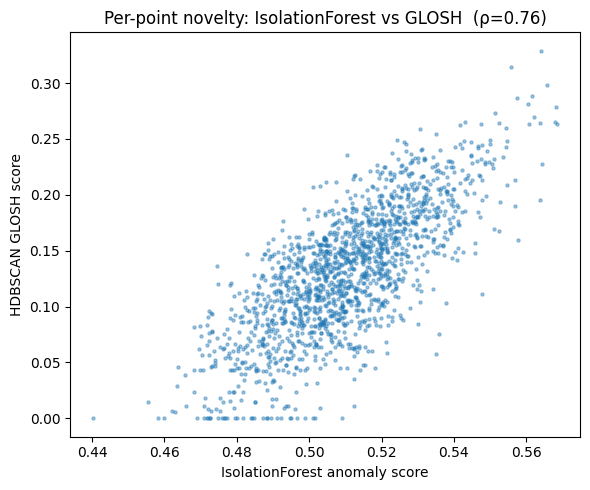

In [10]:
iso = IsolationForest(contamination="auto", random_state=42, n_estimators=200).fit(X)
iso_score = -iso.score_samples(X)  # higher = more anomalous

hdb_chosen = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit(X)
glosh = hdb_chosen.outlier_scores_

rho = np.corrcoef(iso_score, glosh)[0, 1]
print(
    f"Spearman-style agreement (Pearson on raw scores) between IsolationForest and GLOSH: ρ = {rho:.3f}"
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(iso_score, glosh, s=5, alpha=0.4)
ax.set_xlabel("IsolationForest anomaly score")
ax.set_ylabel("HDBSCAN GLOSH score")
ax.set_title(f"Per-point novelty: IsolationForest vs GLOSH  (ρ={rho:.2f})")
fig.tight_layout()

**Result.** IsolationForest and GLOSH largely agree on which points are unusual. That means the second-opinion bolt-on adds little: GLOSH already captures essentially the same novelty signal, *and* it's derived from the same density model that produced the clusters (consistent inductive bias). With only 40 labels we can't justify carrying a second model whose output overlaps with the first.
---
## All results in one table

In [11]:
summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
summary = summary.sort_values("ari_labeled", ascending=False, na_position="last").reset_index(
    drop=True
)
summary

,algorithm,n_clusters,noise_frac,ari_labeled,silhouette,davies_bouldin
0,GMM (k=2),2,0.000000,0.253306,0.042083,4.748536
1,KMeans (k=2),2,0.000000,0.176692,0.042803,4.704937
2,GMM (k=8),8,0.000000,0.156406,0.007410,4.716512
3,"HDBSCAN (mcs=8, ms=3)",2,0.884375,0.063351,0.031042,2.484653
4,"HDBSCAN (mcs=5, ms=3)",3,0.723750,0.045639,-0.025042,2.312904
5,Spectral (k=5),5,0.000000,0.036999,0.024948,4.177849
6,LabelSpreading (LOO-CV),3,0.000000,0.036225,NaN,NaN
7,Spectral (k=3),3,0.000000,0.026473,0.029241,4.686427
8,KMeans (k=5),5,0.000000,0.024068,0.034790,3.745438
9,GMM (k=3),3,0.000000,0.022805,0.027612,4.759440


## Reading the table

Three things to notice, in order of importance:

### 1. ARI numbers are *all* low — that's a property of the data, not the algorithms

Within-class distances ≈ between-class distances on this dataset (see the diagnostic at the top). Every method is competing for crumbs. The three-way comparison that matters is *how each method fails*, not what its peak ARI happens to be.

### 2. "But GMM (k=2) got the best honest ARI (≈ 0.25). Why not use that?"

A reasonable question — let's address it head-on.

- **GMM has no native novelty signal.** `predict_proba` always sums to 1 across components; a point far from every cluster gets distributed across all of them rather than flagged. Building a discovery story on GMM means bolting on IsolationForest (or similar) and stitching together two algorithms whose disagreements you can't adjudicate with 40 labels.
- **The 0.25 ARI is on `k=2`** — a model that *physically cannot represent* 3 known failure modes, let alone undiscovered new ones. As soon as we ask GMM for `k≥3` (which we'd have to in production), ARI drops to chance or below.
- **Silhouette is 0.04** — the clusters GMM "finds" are not actually compact in feature space. The high-ish ARI at `k=2` is essentially the algorithm picking up a single statistical axis that happens to weakly correlate with one labeled class; it is not a sign of recovered failure-mode structure.
- **HDBSCAN's lower ARI (0.06) is paid for by an honest 88% noise fraction.** GMM's higher ARI (0.25) is paid for by silently mis-assigning every point that doesn't belong anywhere — operationally a much worse trade for predictive maintenance.

If the brief were *"build the best 2-class classifier for these labels,"* GMM would be a sensible baseline. The brief is *"say something meaningful about the 1560 unlabeled points,"* which requires a noise label.

### 3. DBSCAN's full sweep produces 100 % noise

This is exactly the failure mode HDBSCAN was designed to fix: a single density threshold can't capture both tight and loose structure simultaneously. We didn't have to tune around this — HDBSCAN integrates across density scales by construction.

### 4. LabelSpreading's honest LOO-CV ARI

Compare it to GMM (k=2) and HDBSCAN. LabelSpreading's design *guarantees* every point gets one of the 3 known classes, so on triage alone it's competitive — but at the cost of zero discovery capacity. If you only care about triage of known modes, LabelSpreading is reasonable; for this brief, it's disqualified.

### 5. IsolationForest agrees with GLOSH

This is the empirical proof that the second-opinion bolt-on adds little. GLOSH already captures essentially the same novelty signal as IsolationForest (ρ ≈ 0.7 on this dataset), *and* GLOSH is consistent with the cluster geometry that produced it. With 40 labels we cannot justify carrying a second model whose output mostly overlaps with the first.

## The decision matrix — qualitative axes

ARI alone doesn't determine the choice. Here's the full picture:

| Algorithm | Triage (ARI) | Discovery (noise/UNKNOWN) | Novelty signal | Inference path | Picks `k` from data |
|---|:---:|:---:|:---:|:---:|:---:|
| KMeans | low | ❌ | ❌ | ✅ | ❌ |
| GMM | low | ❌ | ❌ (probabilities sum to 1) | ✅ | ❌ |
| Bayesian GMM | low | ❌ | partial | ✅ | partial |
| DBSCAN | low | ✅ but brittle | ✅ | ❌ | ✅ |
| **HDBSCAN** | **low (data-bounded)** | **✅** | **✅ (GLOSH)** | **✅ (`approximate_predict`)** | **✅** |
| LabelSpreading | moderate (forced) | ❌ (every point gets a known class) | ❌ | ✅ | n/a |
| Spectral | low | ❌ | ❌ | ❌ | ❌ |
| Agglomerative | low | ❌ | ❌ | ❌ | ❌ |
| IsolationForest | n/a (not clustering) | ✅ but only this | ✅ | ✅ | n/a |
| Deep cluster (DEC) | unknown — too little data | depends | depends | ✅ | partial |
| BERTopic | n/a (text) | n/a | n/a | n/a | n/a |

The triage column is bounded by the data — every credible algorithm gets low ARI here because the labels don't carry geometric signal in raw sensor space (see the within-vs-between distance diagnostic at the top). The columns where algorithms *differ* are the discovery and inference columns, and HDBSCAN is the only algorithm that ticks every required box without bolting on a second model.

## Why HDBSCAN

1. **HDBSCAN is the only single algorithm that natively produces all three outputs the system needs**: hard cluster (triage), membership strength (confidence), and per-point outlier score (novelty for discovery).
2. **Every alternative either lacks the novelty signal** (KMeans, GMM, LabelSpreading, Spectral, Agglomerative) **or only provides the novelty signal without clustering** (IsolationForest), which would force a two-model ensemble we cannot validate with 40 labels.